# 🎬 Single-Video Deepfake Predictor
**Pipeline:**
1. Load model → run inference on one video
2. Grad-CAM++ spatial explainability
3. SLM natural-language caption

> Set your paths and backend in **Part 1**, then *Run All*.

## Part 0 — Imports

In [1]:
import os
import textwrap
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import timm

warnings.filterwarnings("ignore")

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

c:\Users\fatah.rahimi\Desktop\Models\my_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch : 2.5.1+cu121
CUDA    : True
GPU     : NVIDIA GeForce RTX 3060


## Part 1 — Configuration
**Edit these variables before running.**

In [2]:
# ─────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────
MODEL_PATH  = "../video_model.pth"          # path to your trained .pth
VIDEO_PATH  = r"..\..\..\Data\test\real\03__talking_angry_couch"  # folder containing frame images (.jpg/.png)

# ─────────────────────────────────────────────────
# INFERENCE
# ─────────────────────────────────────────────────
NUM_FRAMES  = 32       # must match training
THRESHOLD   = 0.5     # P(real) >= THRESHOLD → "real"

# ─────────────────────────────────────────────────
# MODEL ARCHITECTURE  (must match training)
# ─────────────────────────────────────────────────
CNN_MODEL   = "efficientnet_b0"
VIT_MODEL   = "deit_tiny_patch16_224"
PROJ_DIM    = 128
LSTM_HIDDEN = 128
LSTM_LAYERS = 1
DROPOUT     = 0.4194

# ─────────────────────────────────────────────────
# GRAD-CAM++
# ─────────────────────────────────────────────────
GRADCAM_N_FRAMES     = 4     # frames to display in the heatmap grid
GRADCAM_TARGET_CLASS = None  # None = predicted class | 0 = fake | 1 = real

# ─────────────────────────────────────────────────
# SLM CAPTION BACKEND
# ─────────────────────────────────────────────────
# Options: "ollama" | "anthropic"
SLM_BACKEND        = "ollama"
SLM_MAX_NEW_TOKENS = 220
CAM_REGION_THRESHOLD = 0.6
SLM_TOP_K_FRAMES   = 3        # how many peak frames to include in the caption

# Ollama (local server — run: ollama serve)
OLLAMA_MODEL = "phi3"
OLLAMA_URL   = "http://localhost:11434/api/generate"

# Anthropic — reads ANTHROPIC_API_KEY from environment
ANTHROPIC_MODEL = "claude-haiku-4-5-20251001"

## Part 2 — Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Part 3 — Model Definition

In [4]:
class CNN_ViT_BiLSTM(nn.Module):
    """
    Hybrid CNN + ViT backbone with BiLSTM temporal aggregation.
    Binary classification: 0 = fake, 1 = real.
    """

    def __init__(self, cnn_model, vit_model, proj_dim, lstm_hidden, lstm_layers, dropout):
        super().__init__()

        self.cnn = timm.create_model(cnn_model, pretrained=False)
        self.cnn.reset_classifier(0)

        self.vit = timm.create_model(vit_model, pretrained=False)
        self.vit.reset_classifier(0)

        with torch.no_grad():
            dummy   = torch.randn(1, 3, 224, 224)
            cnn_dim = self.cnn(dummy).shape[1]
            vit_dim = self.vit(dummy).shape[1]

        self.cnn_proj = nn.Sequential(nn.Linear(cnn_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.vit_proj = nn.Sequential(nn.Linear(vit_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.fusion_norm = nn.LayerNorm(proj_dim * 2)

        self.lstm = nn.LSTM(
            input_size=proj_dim * 2,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else dropout,
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x        = x.view(B * T, C, H, W)
        cnn_feat = self.cnn_proj(self.cnn(x))
        vit_feat = self.vit_proj(self.vit(x))
        fused    = self.fusion_norm(torch.cat([cnn_feat, vit_feat], dim=1))
        seq_feat = fused.view(B, T, -1)
        lstm_out, _ = self.lstm(seq_feat)
        return self.classifier(lstm_out.mean(dim=1))

## Part 4 — Load Trained Weights

In [5]:
model = CNN_ViT_BiLSTM(
    cnn_model=CNN_MODEL,
    vit_model=VIT_MODEL,
    proj_dim=PROJ_DIM,
    lstm_hidden=LSTM_HIDDEN,
    lstm_layers=LSTM_LAYERS,
    dropout=DROPOUT,
).to(device)

assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Loaded  : {MODEL_PATH}")
print(f"Params  : {sum(p.numel() for p in model.parameters()):,}")

Loaded  : ../video_model.pth
Params  : 10,149,437


## Part 5 — Preprocessing Utilities

In [6]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def denorm(tensor):
    """Undo ImageNet normalisation → [0, 1] clipped."""
    return (tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)


def load_video_frames(video_folder, num_frames):
    """Load `num_frames` evenly-spaced frames from a folder of images."""
    IMG_EXTS = (".jpg", ".jpeg", ".png")
    files = sorted([
        os.path.join(video_folder, f)
        for f in os.listdir(video_folder)
        if f.lower().endswith(IMG_EXTS)
    ])
    assert files, f"No image frames found in: {video_folder}"

    indices = np.linspace(0, len(files) - 1, num_frames, dtype=int)
    frames  = [inference_transform(Image.open(files[i]).convert("RGB")) for i in indices]
    return torch.stack(frames, dim=0)   # (T, C, H, W)


def overlay_cam(frame_tensor, cam):
    """Blend Grad-CAM++ heatmap onto a frame tensor → uint8 RGB (H,W,3)."""
    rgb  = (denorm(frame_tensor.unsqueeze(0))[0].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    heat = cv2.cvtColor(
        cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB
    )
    return (0.55 * rgb + 0.45 * heat).astype(np.uint8)


LABEL_MAP = {0: "fake", 1: "real"}
print("Utilities ready.")

Utilities ready.


## Part 6 — Inference

In [7]:
frames_tensor = load_video_frames(VIDEO_PATH, NUM_FRAMES)   # (T, C, H, W)
video_name    = os.path.basename(os.path.normpath(VIDEO_PATH))

model.eval()
with torch.no_grad():
    logit     = model(frames_tensor.unsqueeze(0).to(device))   # (1, 1)
    prob_real = torch.sigmoid(logit).item()

prob_fake   = 1.0 - prob_real
pred_class  = int(prob_real >= THRESHOLD)    # 1 = real, 0 = fake
prediction  = LABEL_MAP[pred_class]
confidence  = round((prob_real if pred_class == 1 else prob_fake) * 100, 1)

print("═" * 50)
print(f"  Video      : {video_name}")
print(f"  Prediction : {prediction.upper()}")
print(f"  Confidence : {confidence}%")
print(f"  P(real)    : {prob_real:.4f}")
print(f"  P(fake)    : {prob_fake:.4f}")
print("═" * 50)

══════════════════════════════════════════════════
  Video      : 03__talking_angry_couch
  Prediction : REAL
  Confidence : 100.0%
  P(real)    : 1.0000
  P(fake)    : 0.0000
══════════════════════════════════════════════════


## Part 7 — Grad-CAM++ Implementation

In [8]:
class GradCAMPlusPlus:
    """
    Grad-CAM++ for the CNN branch of CNN_ViT_BiLSTM.

    Hooks the activation tensor of model.cnn's last Conv2d.
    Works even when CNN backbone weights have requires_grad=False.
    """

    def __init__(self, model):
        self.model      = model
        self._features  = None
        self._gradients = None
        self._hooks     = []
        self._target    = self._find_last_conv(model.cnn)
        self._register()
        print(f"Grad-CAM++ target : {self._target.__class__.__name__}")

    @staticmethod
    def _find_last_conv(module):
        last = None
        for m in module.modules():
            if isinstance(m, nn.Conv2d):
                last = m
        if last is None:
            raise RuntimeError("No Conv2d found in model.cnn")
        return last

    def _register(self):
        def fwd_hook(module, inp, output):
            self._features = output
            def grad_hook(grad):
                self._gradients = grad
            self._hooks.append(output.register_hook(grad_hook))
        self._hooks.append(self._target.register_forward_hook(fwd_hook))

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def generate(self, frames, target_class=None):
        """
        Compute per-frame Grad-CAM++ heatmaps for a single video.

        Args:
            frames       : (T, C, H, W) tensor on device.
            target_class : 0 | 1 | None (uses predicted class).

        Returns:
            cams         : np.ndarray (T, 224, 224) in [0, 1]
            prob_real    : float
            target_class : int
        """
        self._features = self._gradients = None
        x = frames.unsqueeze(0).detach().requires_grad_(True)

        self.model.eval()
        self.model.lstm.train()   # cuDNN LSTM backward needs train()
        try:
            logit     = self.model(x)
            prob_real = torch.sigmoid(logit).item()
            if target_class is None:
                target_class = int(prob_real >= 0.5)
            score = logit if target_class == 1 else -logit
            self.model.zero_grad()
            score.backward()
        finally:
            self.model.lstm.eval()

        assert self._gradients is not None, "Gradient hook did not fire."

        grads    = self._gradients.detach()     # (T, C, h, w)
        features = self._features.detach()      # (T, C, h, w)

        grads_sq  = grads ** 2
        grads_cub = grads ** 3
        denom     = 2 * grads_sq + features * grads_cub
        denom     = torch.where(denom != 0, denom, torch.ones_like(denom))
        alpha     = grads_sq / denom
        weights   = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
        cams      = F.relu((weights * features).sum(dim=1))

        cams = F.interpolate(
            cams.unsqueeze(1), size=(224, 224), mode="bilinear", align_corners=False
        ).squeeze(1).cpu().numpy()

        for i in range(len(cams)):
            mn, mx = cams[i].min(), cams[i].max()
            cams[i] = (cams[i] - mn) / (mx - mn + 1e-8)

        return cams, prob_real, target_class


print("GradCAMPlusPlus ready.")

GradCAMPlusPlus ready.


## Part 8 — Run Grad-CAM++

Grad-CAM++ target : Conv2d


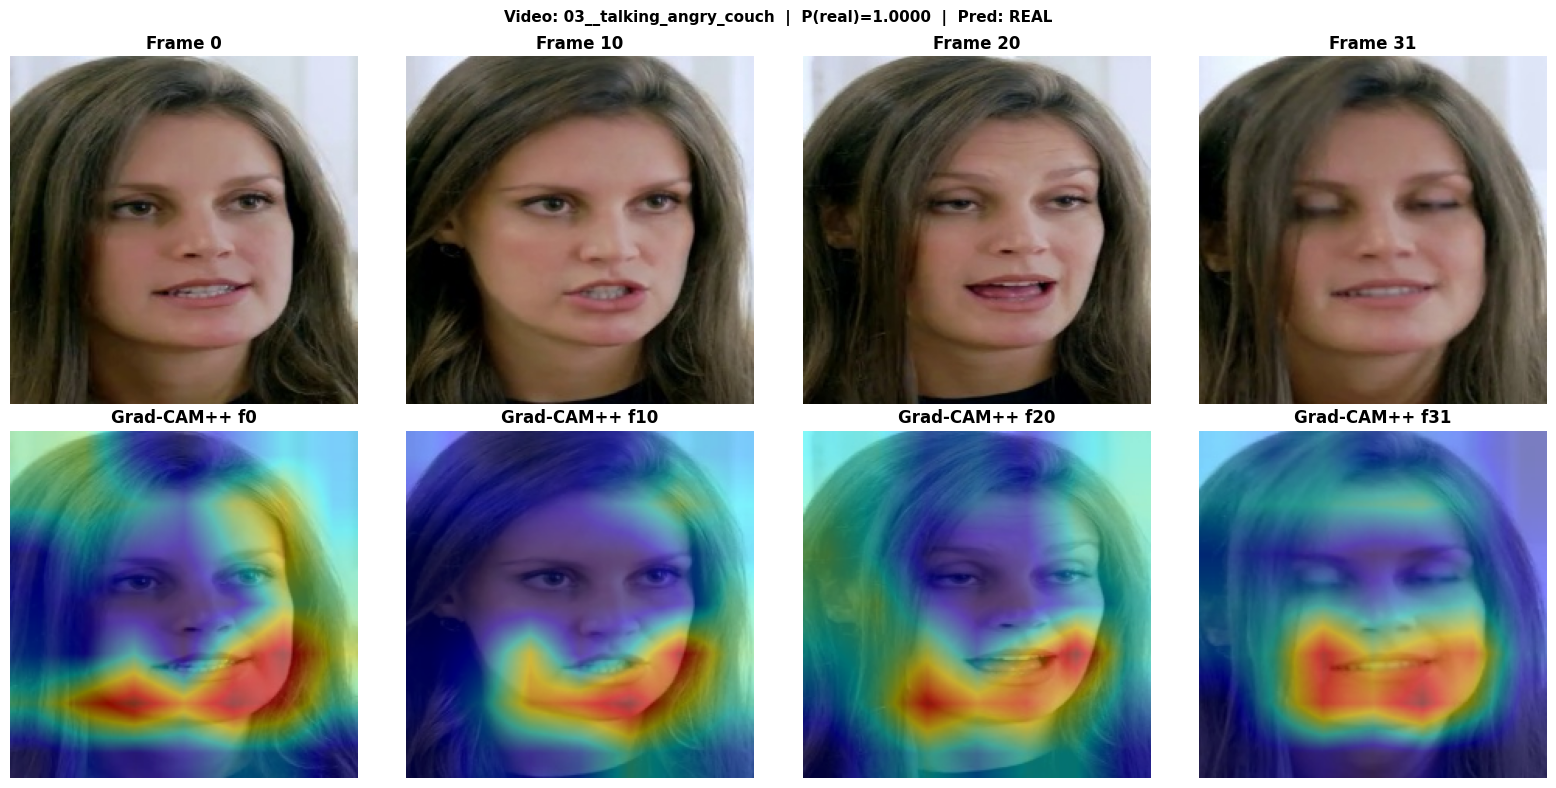

Saved: gradcam_result.png


In [9]:
gcpp = GradCAMPlusPlus(model)
cams, prob_real, pred_class = gcpp.generate(
    frames_tensor.to(device), target_class=GRADCAM_TARGET_CLASS
)
gcpp.remove()

# Select evenly-spaced frames to display
display_frame_idx = np.linspace(0, NUM_FRAMES - 1, GRADCAM_N_FRAMES, dtype=int)

fig, axes = plt.subplots(2, GRADCAM_N_FRAMES, figsize=(4 * GRADCAM_N_FRAMES, 8))

title = f"Video: {video_name}  |  P(real)={prob_real:.4f}  |  Pred: {LABEL_MAP[pred_class].upper()}"
fig.suptitle(title, fontsize=11, fontweight="bold")

for col, fi in enumerate(display_frame_idx):
    # Original frame
    rgb = denorm(frames_tensor[fi].unsqueeze(0))[0].permute(1, 2, 0).numpy()
    axes[0, col].imshow(rgb)
    axes[0, col].set_title(f"Frame {fi}", fontweight="bold")
    axes[0, col].axis("off")

    # Grad-CAM++ overlay
    axes[1, col].imshow(overlay_cam(frames_tensor[fi], cams[fi]))
    axes[1, col].set_title(f"Grad-CAM++ f{fi}", fontweight="bold")
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("gradcam_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gradcam_result.png")

## Part 9 — Temporal Salience Strip
Shows which frames drove the decision most strongly.

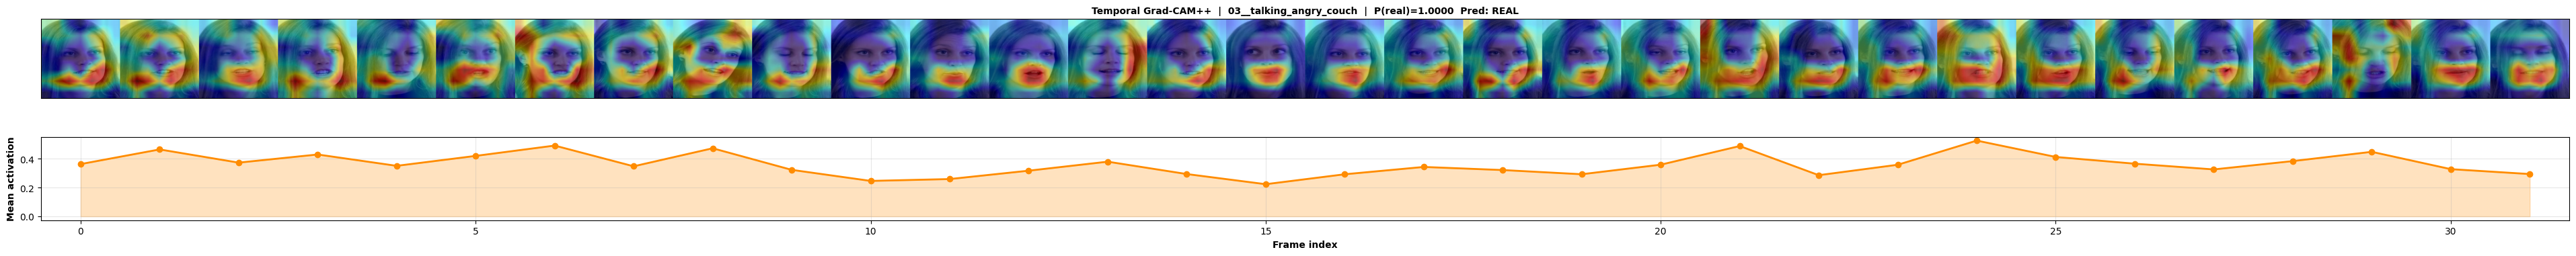

Saved: gradcam_temporal_strip.png


In [10]:
mean_activation = cams.mean(axis=(1, 2))   # (T,)

fig, (ax_strip, ax_line) = plt.subplots(
    2, 1, figsize=(NUM_FRAMES * 1.2, 5),
    gridspec_kw={"height_ratios": [3, 1]}
)

strip_img = np.concatenate(
    [overlay_cam(frames_tensor[i], cams[i]) for i in range(NUM_FRAMES)], axis=1
)
ax_strip.imshow(strip_img)
ax_strip.set_xticks([])
ax_strip.set_yticks([])
ax_strip.set_title(
    f"Temporal Grad-CAM++  |  {video_name}  |  "
    f"P(real)={prob_real:.4f}  Pred: {LABEL_MAP[pred_class].upper()}",
    fontweight="bold", fontsize=10
)

ax_line.plot(range(NUM_FRAMES), mean_activation, marker="o", linewidth=2, color="darkorange")
ax_line.fill_between(range(NUM_FRAMES), mean_activation, alpha=0.25, color="darkorange")
ax_line.set_xlim(-0.5, NUM_FRAMES - 0.5)
ax_line.set_xlabel("Frame index", fontweight="bold")
ax_line.set_ylabel("Mean activation", fontweight="bold")
ax_line.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gradcam_temporal_strip.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gradcam_temporal_strip.png")

## Part 10 — SLM Caption Setup

| Backend | Requirement |
|---------|-------------|
| `ollama` | `ollama serve` running locally |
| `anthropic` | `ANTHROPIC_API_KEY` in environment |

In [11]:
def activation_region(cam, threshold=0.6):
    """Return a human-readable spatial description of the hottest CAM region."""
    mask = cam >= threshold
    rows, cols = np.where(mask)
    if len(rows) == 0:
        return "whole frame"
    cy = ((rows.min() + rows.max()) / 2) / cam.shape[0]
    cx = ((cols.min() + cols.max()) / 2) / cam.shape[1]
    v  = "upper" if cy < 0.4 else ("lower" if cy > 0.6 else "mid")
    h  = "left"  if cx < 0.4 else ("right" if cx > 0.6 else "center")
    return f"{v}-{h} area"


def extract_cam_signals(cams, top_k=3, threshold=0.6):
    """Return the top-k highest-activation frames and their spatial regions."""
    mean_act    = cams.mean(axis=(1, 2))
    peak_frames = np.argsort(mean_act)[::-1][:top_k].tolist()
    regions     = [activation_region(cams[i], threshold) for i in peak_frames]
    return peak_frames, regions, mean_act


def build_prompt(video_name, pred_class, prob_real, peak_frames, regions):
    label = "FAKE" if pred_class == 0 else "REAL"
    conf  = round((prob_real if pred_class == 1 else 1 - prob_real) * 100, 1)
    frame_desc = ", ".join(f"frame {fi} ({reg})" for fi, reg in zip(peak_frames, regions))
    return (
        f"You are a deepfake detection analyst. Explain the following result "
        f"to a non-technical user in 3-4 clear sentences.\n\n"
        f"Video: {video_name}\n"
        f"Verdict: {label} with {conf}% confidence\n"
        f"Key evidence frames (highest Grad-CAM++ activation): {frame_desc}\n\n"
        f"Explain what the model likely detected, which facial regions triggered "
        f"the decision, and what this means for the video's authenticity. "
        f"Use plain English. No technical jargon."
    )


def call_ollama(prompt):
    payload = {
        "model" : OLLAMA_MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"num_predict": SLM_MAX_NEW_TOKENS, "temperature": 0.7},
    }
    resp = requests.post(OLLAMA_URL, json=payload, timeout=120)
    resp.raise_for_status()
    return resp.json()["response"].strip()


def call_anthropic(prompt):
    import anthropic
    client = anthropic.Anthropic()   # reads ANTHROPIC_API_KEY from env
    msg = client.messages.create(
        model=ANTHROPIC_MODEL,
        max_tokens=SLM_MAX_NEW_TOKENS,
        messages=[{"role": "user", "content": prompt}],
    )
    return msg.content[0].text.strip()


def generate_caption(prompt):
    if SLM_BACKEND == "anthropic":
        return call_anthropic(prompt)
    else:   # default: ollama
        return call_ollama(prompt)


print(f"SLM backend : {SLM_BACKEND}")

SLM backend : ollama


## Part 11 — Generate SLM Caption

In [12]:
peak_frames, regions, mean_act = extract_cam_signals(
    cams, top_k=SLM_TOP_K_FRAMES, threshold=CAM_REGION_THRESHOLD
)

prompt = build_prompt(video_name, pred_class, prob_real, peak_frames, regions)

print("Generating caption…")
caption = generate_caption(prompt)

sep = "═" * 64
print(f"\n{sep}")
print(f"  Video      : {video_name}")
print(f"  Verdict    : {LABEL_MAP[pred_class].upper()}  P(real)={prob_real:.4f}")
print(f"  Peak frames: {peak_frames}")
print(f"  Regions    : {regions}")
print(f"\n  Caption:\n")
print(f"  {caption}")
print(sep)

Generating caption…

════════════════════════════════════════════════════════════════
  Video      : 03__talking_angry_couch
  Verdict    : REAL  P(real)=1.0000
  Peak frames: [24, 6, 21]
  Regions    : ['mid-center area', 'mid-center area', 'mid-center area']

  Caption:

  The analysis of a funny talking couch video shows that it is very real; we are almost certain about its authenticity (100% confidence). The model looked closely at three specific moments in time where the person's face was clear and centered on screen, which seem to be crucial for recognizing their emotions. Because these parts of the video matched a happy or neutral expression typical in real videos without manipulation, we think this is not fake footage but an actual couch talking with someone who might have been playing along as part of a prank or special effect.
════════════════════════════════════════════════════════════════


## Part 12 — Final Visual: Heatmap + Caption

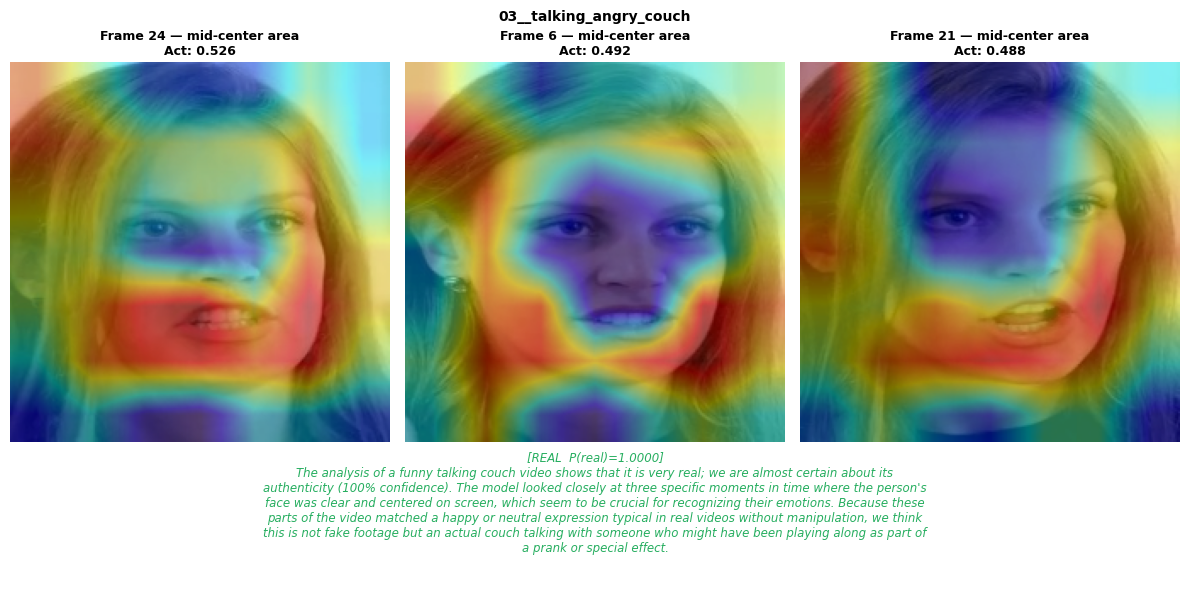

Saved: explained_result.png


In [13]:
n_show = min(SLM_TOP_K_FRAMES, len(peak_frames))

fig = plt.figure(figsize=(n_show * 4, 6))
gs  = fig.add_gridspec(2, n_show, height_ratios=[4, 1.4])

for col, fi in enumerate(peak_frames[:n_show]):
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(overlay_cam(frames_tensor[fi], cams[fi]))
    ax.set_title(
        f"Frame {fi} — {regions[col]}\nAct: {mean_act[fi]:.3f}",
        fontsize=9, fontweight="bold"
    )
    ax.axis("off")

# Caption panel
ax_txt = fig.add_subplot(gs[1, :])
ax_txt.axis("off")
wrapped = "\n".join(textwrap.wrap(caption, width=110))
verdict = LABEL_MAP[pred_class].upper()
color   = "#c0392b" if pred_class == 0 else "#27ae60"

ax_txt.text(
    0.5, 0.95,
    f"[{verdict}  P(real)={prob_real:.4f}]\n{wrapped}",
    ha="center", va="top", fontsize=8.5,
    color=color, style="italic",
    transform=ax_txt.transAxes,
)

fig.suptitle(f"{video_name}", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig("explained_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: explained_result.png")

## Part 13 — Summary

In [14]:
outputs = [
    ("gradcam_result.png",        "Original frames + Grad-CAM++ overlays"),
    ("gradcam_temporal_strip.png","Temporal salience strip + activation timeline"),
    ("explained_result.png",      "Peak frames + heatmap + SLM caption"),
]

print(f"Video      : {video_name}")
print(f"Prediction : {LABEL_MAP[pred_class].upper()}")
print(f"Confidence : {confidence}%")
print(f"P(real)    : {prob_real:.4f}")
print(f"P(fake)    : {1 - prob_real:.4f}")
print(f"Peak frames: {peak_frames}")
print(f"Regions    : {regions}")
print()
print("Caption:")
print(caption)
print()
print("Output files:")
for fname, desc in outputs:
    exists = "✓" if os.path.exists(fname) else " "
    print(f"  [{exists}] {fname:<35} {desc}")

Video      : 03__talking_angry_couch
Prediction : REAL
Confidence : 100.0%
P(real)    : 1.0000
P(fake)    : 0.0000
Peak frames: [24, 6, 21]
Regions    : ['mid-center area', 'mid-center area', 'mid-center area']

Caption:
The analysis of a funny talking couch video shows that it is very real; we are almost certain about its authenticity (100% confidence). The model looked closely at three specific moments in time where the person's face was clear and centered on screen, which seem to be crucial for recognizing their emotions. Because these parts of the video matched a happy or neutral expression typical in real videos without manipulation, we think this is not fake footage but an actual couch talking with someone who might have been playing along as part of a prank or special effect.

Output files:
  [✓] gradcam_result.png                  Original frames + Grad-CAM++ overlays
  [✓] gradcam_temporal_strip.png          Temporal salience strip + activation timeline
  [✓] explained_result.